# Wind-Aware Isochrones

**Purpose:** Given a base airport, an aircraft, an endurance budget, and an on-station observation requirement, *which sites are feasible?* This notebook walks through `compute_isochrone`, which answers that question with a polygon around the base.

**Metadata:**
- **Audience:** Intermediate
- **Runtime:** ~70 sec (still air); ~3 min (with MERRA-2)
- **Requires internet:** Optional (MERRA-2 section; Cartopy may also download Natural Earth basemap files on first use)
- **Credentials:** Optional NASA Earthdata token for MERRA-2 (skip that section otherwise)
- **Optional dependencies:** `hyplan[winds]` for MERRA-2; `cartopy` for static basemap plots

**What you will learn:**
- The three isochrone modes — `one_way`, `round_trip`, `return_safe`
- How to compute a still-air isochrone for a research aircraft
- How wind shifts the boundary (constant wind + MERRA-2 reanalysis)
- How to put isochrone polygons on a geographic basemap
- How to render an isochrone as a Folium map
- How `ray_strategy` improves vertex spacing for different recovery airports
- How `start.altitude_msl` and `cruise_altitude` interact (pre-flight vs in-flight)

## Conceptual model

An isochrone is the boundary of all locations reachable from a starting state, given a time budget and (optionally) the requirement to land at a designated return destination. Per ray (every 5° in azimuth by default), the algorithm:

1. **Brackets** the reachable distance by doubling a candidate distance until the leg-time constraint is violated.
2. **Binary-searches** within the bracket to ~0.5 nmi precision.
3. **Records** the converged boundary point plus diagnostics (outbound time, return time, headwind components, limiting leg).

Each leg is timed by integrating the aircraft's calibrated `_climb` / `cruise` / `_descend` profiles with along-track wind sampled at the leg midpoint.

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
from IPython.display import display


def _show_plot():
    """Display matplotlib figures without Agg-backend warnings."""
    if matplotlib.get_backend().lower() == "agg":
        for num in plt.get_fignums():
            display(plt.figure(num))
    else:
        getattr(plt, "show")()
import cartopy.crs as ccrs

from hyplan import (
    NASA_GIII, NASA_GV, NASA_P3, KingAirB200,
    Waypoint, ureg,
    compute_isochrone, compute_concentric_isochrones,
    compute_refuel_isochrone, evaluate_target_reachability,
    isochrone_polygon, plot_isochrone, plot_isochrone_static,
)
from hyplan.airports import Airport, initialize_data
from hyplan.winds import StillAirField, ConstantWindField

# Load the airport database once (used for KEFD, KCOS below).
initialize_data()

PLATE_CARREE = ccrs.PlateCarree()

# Faster exploratory settings for the tutorial.  For publication-quality
# boundaries, use the API defaults (5° rays, 0.5 nmi tolerance).
AZIMUTH_RESOLUTION_DEG = 10.0
DISTANCE_TOLERANCE_NMI = 2.0



# `plot_isochrone_static` lives in the library now (hyplan/plotting.py).
# It accepts either a single GeoDataFrame or a list of (gdf, color, label)
# tuples for layered comparison, and auto-handles concentric / refuel
# inputs.  Earlier sections reference it as `plot_isochrone_layers`; alias
# kept for backward compatibility.
plot_isochrone_layers = plot_isochrone_static


## 1. Pre-flight planning: where can a B-200 observe from KEFD?

Ellington Field (KEFD), home of NASA Johnson Space Center aircraft operations.  King Air B-200, 5-hour endurance budget, FL250 cruise, 30-minute reserve, and 2-hour on-station observation requirement.  **`mode="round_trip"`** — out and back from KEFD.

`compute_isochrone` accepts an `Airport` directly; HyPlan uses the airport coordinates and runway elevation as the starting state.

In [15]:
kefd = Airport("KEFD")
ac = KingAirB200()

cruise_altitude = 25000 * ureg.feet
mission_budget = 5 * ureg.hour
on_station = 120 * ureg.minute
reserve = 30 * ureg.minute

gdf_calm = compute_isochrone(
    aircraft=ac,
    start=kefd,
    budget=mission_budget,
    cruise_altitude=cruise_altitude,
    mode="round_trip",
    on_station_time=on_station,
    reserve=reserve,
    wind_source=StillAirField(),
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)

print(f"{len(gdf_calm)} rays, mean radius {gdf_calm.distance_nmi.mean():.0f} nmi, "
      f"limiting leg breakdown: {gdf_calm.limiting_leg.value_counts().to_dict()}")
gdf_calm[[
    "azimuth_deg", "distance_nmi", "outbound_time_min",
    "return_time_min", "total_time_min", "time_slack_min",
]].head().round(2)

36 rays, mean radius 290 nmi, limiting leg breakdown: {'on_station': 36}


,azimuth_deg,distance_nmi,outbound_time_min,return_time_min,total_time_min,time_slack_min
0,0.0,290.0,76.37,73.57,269.94,0.06
1,10.0,290.0,76.37,73.57,269.94,0.06
2,20.0,290.0,76.37,73.57,269.94,0.06
3,30.0,290.0,76.37,73.57,269.94,0.06
4,40.0,290.0,76.37,73.57,269.94,0.06


Still-air round-trip is symmetric — every ray reaches the same distance to within the binary-search tolerance. The 120-minute on-station requirement plus 30-minute reserve consume 150 minutes of the 300-minute budget; the remaining ~150 minutes is split between outbound and return cruise, plus climb and descent overhead.

## 2. Wind effects: constant 60 kt jet stream from west

Same B-200 setup, but with a 60-knot wind from 270° (west). Eastbound rays get a tailwind on outbound and a headwind on return; westbound rays get the opposite. **For round-trip, the asymmetry is small** — the wind largely cancels over a closed loop. The bigger effect shows up when only one leg is wind-affected.

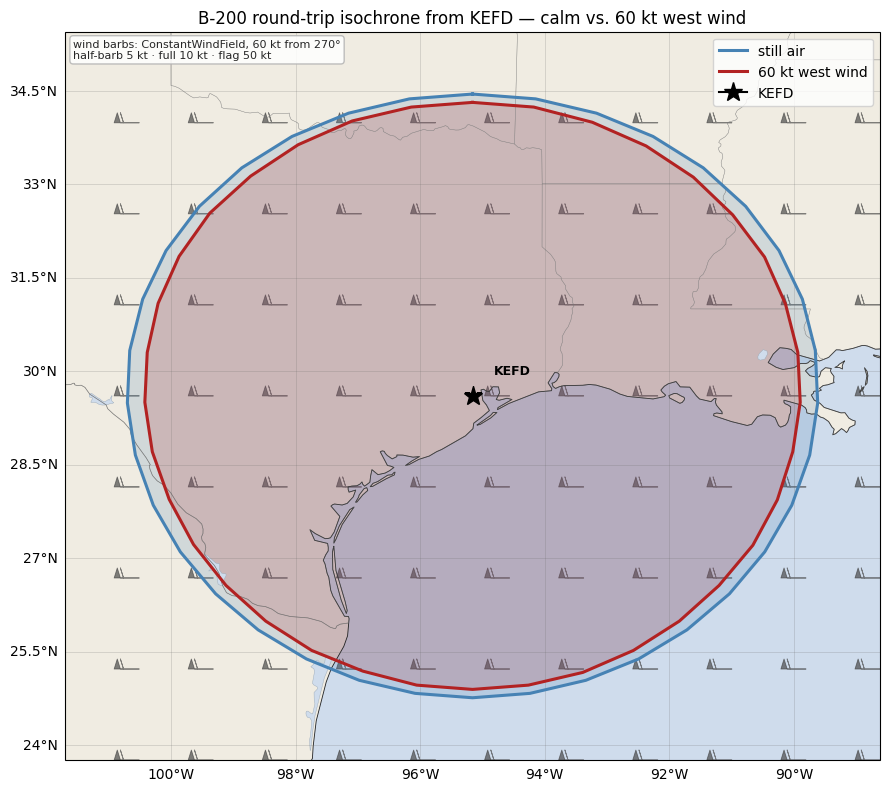

calm:  mean 290 nmi, range 290-290 nmi
wind:  mean 279 nmi, range 275-282 nmi
east-vs-west spread under wind: 0.0 nmi


In [16]:
wind = ConstantWindField(60 * ureg.knot, wind_from_deg=270.0)

gdf_wind = compute_isochrone(
    aircraft=ac,
    start=kefd,
    budget=mission_budget,
    cruise_altitude=cruise_altitude,
    mode="round_trip",
    on_station_time=on_station,
    reserve=reserve,
    wind_source=wind,
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)

plot_isochrone_layers(
    [
        (gdf_calm, "steelblue", "still air"),
        (gdf_wind, "firebrick", "60 kt west wind"),
    ],
    points=[{"lon": kefd.longitude, "lat": kefd.latitude, "label": "KEFD", "color": "black"}],
    title="B-200 round-trip isochrone from KEFD — calm vs. 60 kt west wind",
    wind_field=wind,
    wind_altitude=cruise_altitude,
    wind_caption=(
        "wind barbs: ConstantWindField, 60 kt from 270°\n"
        "half-barb 5 kt · full 10 kt · flag 50 kt"
    ),
)
_show_plot()

print(f"calm:  mean {gdf_calm.distance_nmi.mean():.0f} nmi, range "
      f"{gdf_calm.distance_nmi.min():.0f}-{gdf_calm.distance_nmi.max():.0f} nmi")
print(f"wind:  mean {gdf_wind.distance_nmi.mean():.0f} nmi, range "
      f"{gdf_wind.distance_nmi.min():.0f}-{gdf_wind.distance_nmi.max():.0f} nmi")
print(f"east-vs-west spread under wind: "
      f"{abs(gdf_wind.set_index('azimuth_deg').loc[90, 'distance_nmi'] - gdf_wind.set_index('azimuth_deg').loc[270, 'distance_nmi']):.1f} nmi")

## 3. One-way reach: where can the aircraft be after 3 hours?

**`mode="one_way"`** — single-leg reach, ignoring return.  Useful for opportunistic in-flight re-tasking when the aircraft is already airborne, or when planning a transit to a downrange operating base where recovery happens elsewhere.

Wind effects on a one-way leg are larger than on a round-trip because there's no return leg to partially cancel the wind: tailwind directly extends reach, headwind directly contracts it.


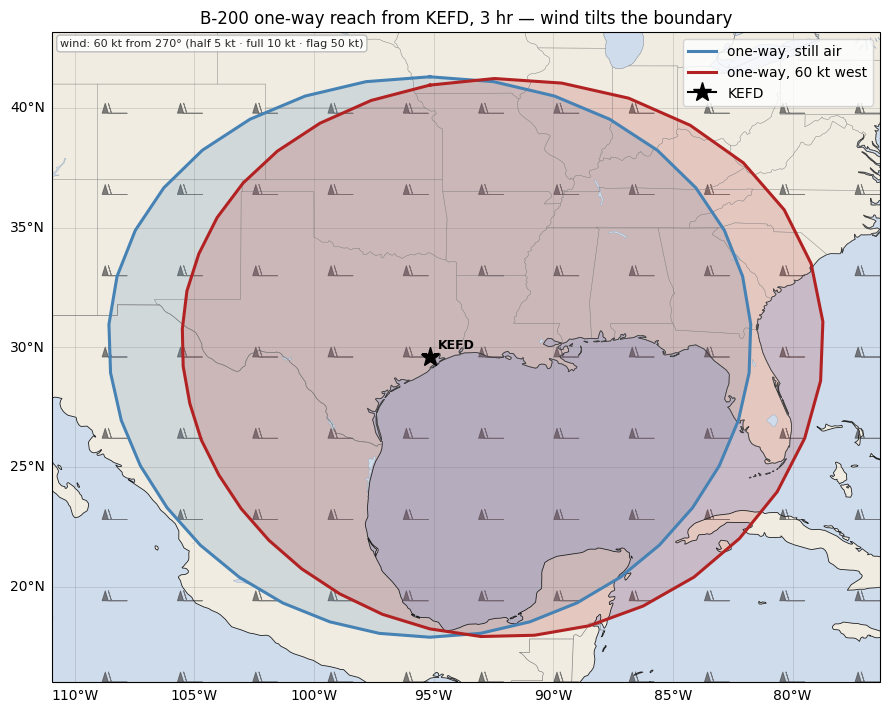

one-way wind: east 860 nmi, west 540 nmi, ratio 1.59


In [17]:
gdf_one_way_calm = compute_isochrone(
    aircraft=ac, start=kefd, budget=3 * ureg.hour,
    cruise_altitude=cruise_altitude, mode="one_way",
    wind_source=StillAirField(),
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)
gdf_one_way_wind = compute_isochrone(
    aircraft=ac, start=kefd, budget=3 * ureg.hour,
    cruise_altitude=cruise_altitude, mode="one_way",
    wind_source=wind,
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)

plot_isochrone_layers(
    [
        (gdf_one_way_calm, "steelblue", "one-way, still air"),
        (gdf_one_way_wind, "firebrick", "one-way, 60 kt west"),
    ],
    points=[{"lon": kefd.longitude, "lat": kefd.latitude, "label": "KEFD", "color": "black"}],
    title="B-200 one-way reach from KEFD, 3 hr — wind tilts the boundary",
    wind_field=wind,
    wind_altitude=cruise_altitude,
    wind_caption="wind: 60 kt from 270° (half 5 kt · full 10 kt · flag 50 kt)",
)
_show_plot()

east = gdf_one_way_wind.set_index("azimuth_deg").loc[90, "distance_nmi"]
west = gdf_one_way_wind.set_index("azimuth_deg").loc[270, "distance_nmi"]
print(f"one-way wind: east {east:.0f} nmi, west {west:.0f} nmi, ratio {east/west:.2f}")

## 4. Return-safe with a different recovery airport

**`mode="return_safe"`** — fly out, observe, recover at a *different* airport. Common when targets are far from base. Here, the B-200 departs KEFD and must recover at KLBB (Lubbock, Texas) within the same 5-hour budget.

This section keeps the ray strategy at its default (`"uniform"`) so the operational meaning of `return_safe` is isolated from the geometry-quality discussion in the next section.


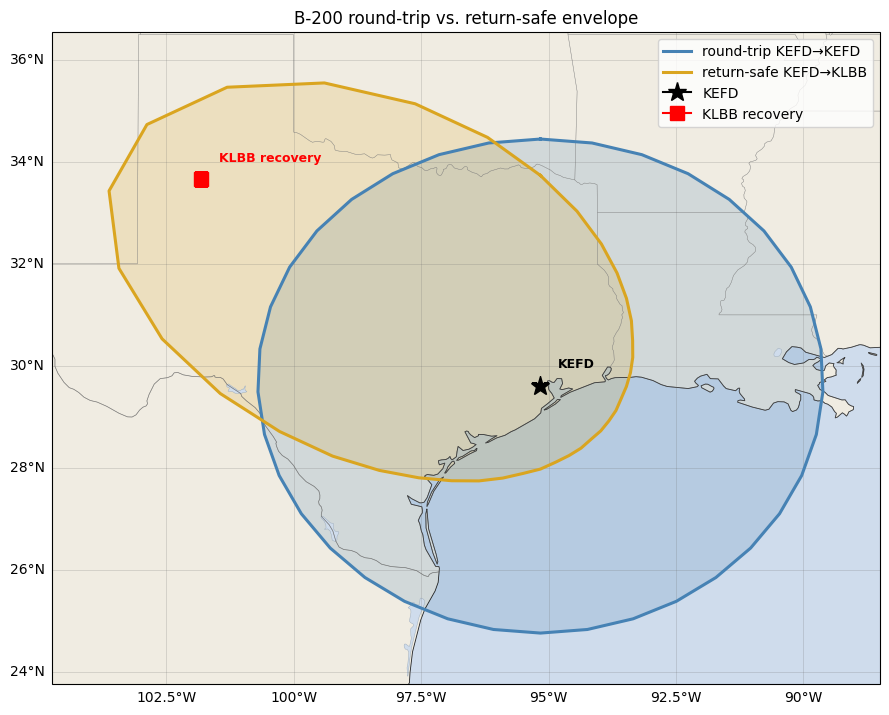

return-safe biases the envelope toward KLBB — areas closer to KLBB are reachable; areas in the opposite direction are less reachable because the recovery leg is longer.
return-safe: 36 rays, strategy=uniform


In [18]:
klbb = Airport("KLBB")

gdf_return = compute_isochrone(
    aircraft=ac,
    start=kefd,
    budget=mission_budget,
    cruise_altitude=cruise_altitude,
    mode="return_safe",
    return_destination=klbb,
    on_station_time=on_station,
    reserve=reserve,
    wind_source=StillAirField(),
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)

plot_isochrone_layers(
    [
        (gdf_calm, "steelblue", "round-trip KEFD→KEFD"),
        (gdf_return, "goldenrod", "return-safe KEFD→KLBB"),
    ],
    points=[
        {"lon": kefd.longitude, "lat": kefd.latitude, "label": "KEFD", "color": "black"},
        {"lon": klbb.longitude, "lat": klbb.latitude,
         "label": "KLBB recovery", "color": "red",
         "marker": "s", "markersize": 10},
    ],
    title="B-200 round-trip vs. return-safe envelope",
)
_show_plot()

print("return-safe biases the envelope toward KLBB — areas closer to KLBB "
      "are reachable; areas in the opposite direction are less reachable "
      "because the recovery leg is longer.")
print(f"return-safe: {len(gdf_return)} rays, strategy={gdf_return.attrs['effective_ray_strategy']}")


## 5. Ray strategy: uniform vs. ellipse/adaptive sampling

When the recovery airport differs from the start, the feasible region is closer to a two-focus ellipse than a start-centered circle. A uniform azimuth sweep still solves the right boundary, but it can crowd vertices near the departure side and undersample the recovery side.

`ray_strategy="ellipse"` keeps the same nominal ray count but chooses bearings from a two-focus ellipse approximation. `ray_strategy="ellipse_adaptive"` starts with that ellipse and then inserts midpoint rays where the solved boundary still has long chords. This is a plotting / polygon-quality setting; it does not change the underlying leg-time physics.


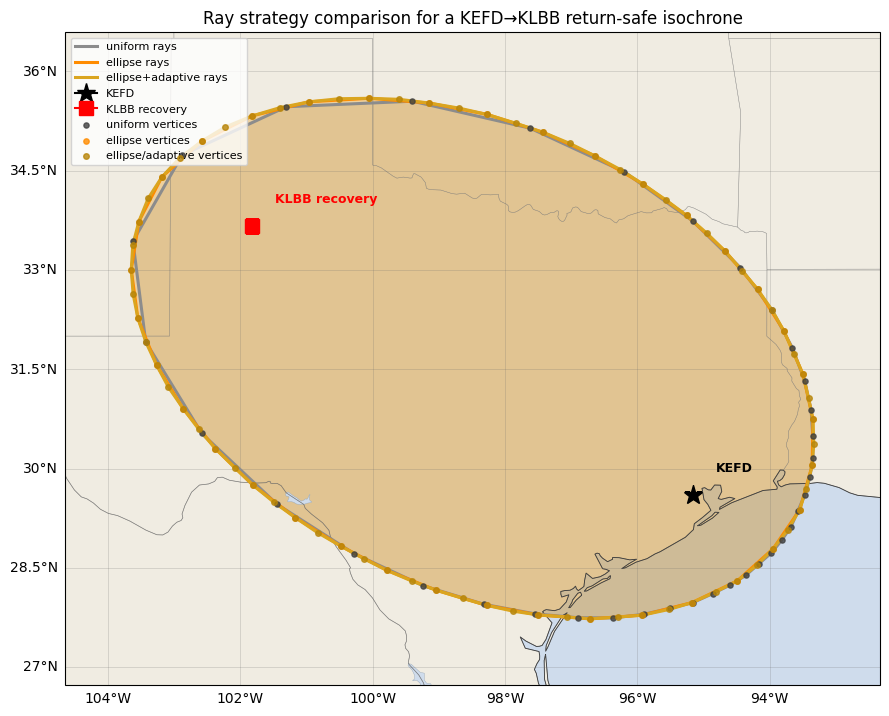

uniform         : 36 rays, effective=uniform, azimuth spacing range=10.0–10.0°
ellipse         : 36 rays, effective=ellipse, azimuth spacing range=4.7–28.4°
ellipse/adaptive: 72 rays, effective=ellipse_adaptive, azimuth spacing range=2.4–14.2°


In [19]:
common_return_safe = dict(
    aircraft=ac,
    start=kefd,
    budget=mission_budget,
    cruise_altitude=cruise_altitude,
    mode="return_safe",
    return_destination=klbb,
    on_station_time=on_station,
    reserve=reserve,
    wind_source=StillAirField(),
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)

gdf_return_uniform = compute_isochrone(
    **common_return_safe,
    ray_strategy="uniform",
)
gdf_return_ellipse = compute_isochrone(
    **common_return_safe,
    ray_strategy="ellipse",
)
gdf_return_ellipse_adaptive = compute_isochrone(
    **common_return_safe,
    ray_strategy="ellipse_adaptive",
    adaptive_spacing_nmi=40.0,
    max_adaptive_rays=90,
)

fig, ax = plot_isochrone_layers(
    [
        (gdf_return_uniform, "0.55", "uniform rays"),
        (gdf_return_ellipse, "darkorange", "ellipse rays"),
        (gdf_return_ellipse_adaptive, "goldenrod", "ellipse+adaptive rays"),
    ],
    points=[
        {"lon": kefd.longitude, "lat": kefd.latitude, "label": "KEFD", "color": "black"},
        {"lon": klbb.longitude, "lat": klbb.latitude,
         "label": "KLBB recovery", "color": "red",
         "marker": "s", "markersize": 10},
    ],
    title="Ray strategy comparison for a KEFD→KLBB return-safe isochrone",
)

for gdf, color, label, size in [
    (gdf_return_uniform, "0.25", "uniform vertices", 14),
    (gdf_return_ellipse, "darkorange", "ellipse vertices", 15),
    (gdf_return_ellipse_adaptive, "darkgoldenrod", "ellipse/adaptive vertices", 16),
]:
    ax.scatter(
        gdf.geometry.x, gdf.geometry.y,
        s=size, color=color, alpha=0.8, transform=PLATE_CARREE,
        label=label, zorder=7,
    )
ax.legend(loc="upper left", fontsize=8)
_show_plot()

for label, gdf in [
    ("uniform", gdf_return_uniform),
    ("ellipse", gdf_return_ellipse),
    ("ellipse/adaptive", gdf_return_ellipse_adaptive),
]:
    az = np.sort(gdf["azimuth_deg"].to_numpy())
    spacings = np.diff(np.r_[az, az[0] + 360])
    print(
        f"{label:16s}: {len(gdf):2d} rays, "
        f"effective={gdf.attrs['effective_ray_strategy']}, "
        f"azimuth spacing range={spacings.min():.1f}–{spacings.max():.1f}°"
    )


## 6. In-flight re-tasking: where can the aircraft go from its current position?

Aircraft is already airborne at FL250 over the central Gulf of Mexico (typical observation altitude for atmospheric / ocean in-situ work) with 4 hours of fuel remaining.  Where can it go and still recover safely at KEFD with a 30-minute reserve?

Pass `start = current position at cruise altitude`.  The leg-timing engine sees `start.altitude_msl == cruise_altitude` and skips the climb phase — same code path, no special branch.


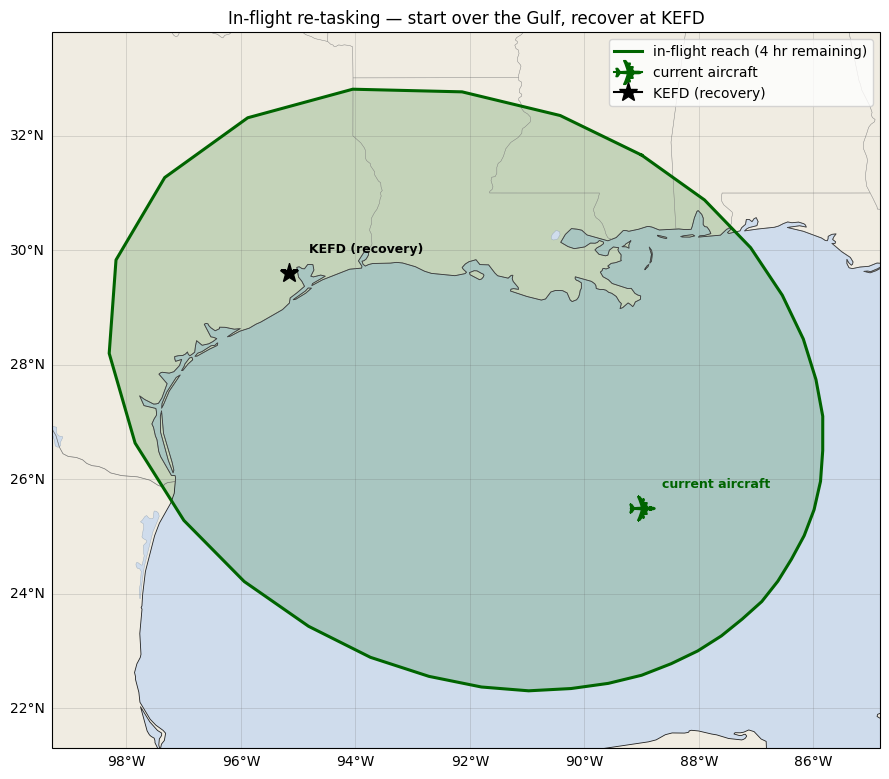

limiting-leg breakdown: {'return': 25, 'outbound': 11}


In [20]:
current = Waypoint(
    latitude=25.5, longitude=-89.0, heading=0.0,
    altitude_msl=cruise_altitude, name="Gulf observation",
)

gdf_inflight = compute_isochrone(
    aircraft=ac,
    start=current,
    budget=4 * ureg.hour,
    mode="return_safe",
    return_destination=kefd,
    on_station_time=30 * ureg.minute,
    reserve=30 * ureg.minute,
    wind_source=StillAirField(),
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)

plot_isochrone_layers(
    [(gdf_inflight, "darkgreen", "in-flight reach (4 hr remaining)")],
    points=[
        {"lon": current.longitude, "lat": current.latitude,
         "label": "current aircraft", "color": "darkgreen",
         "marker": "$✈$", "markersize": 18},
        {"lon": kefd.longitude, "lat": kefd.latitude,
         "label": "KEFD (recovery)", "color": "black"},
    ],
    title="In-flight re-tasking — start over the Gulf, recover at KEFD",
)
_show_plot()

print("limiting-leg breakdown:", gdf_inflight.limiting_leg.value_counts().to_dict())


## 7. Multi-aircraft fleet comparison

Same base, same budget — different aircraft give different envelopes.  The four shown here span the typical NASA airborne-science range: two long-range business jets (G-III, G-V) at high altitude, a four-engine turboprop (P-3) for endurance / payload, and a twin turboprop (B-200) for low-altitude in-situ work.


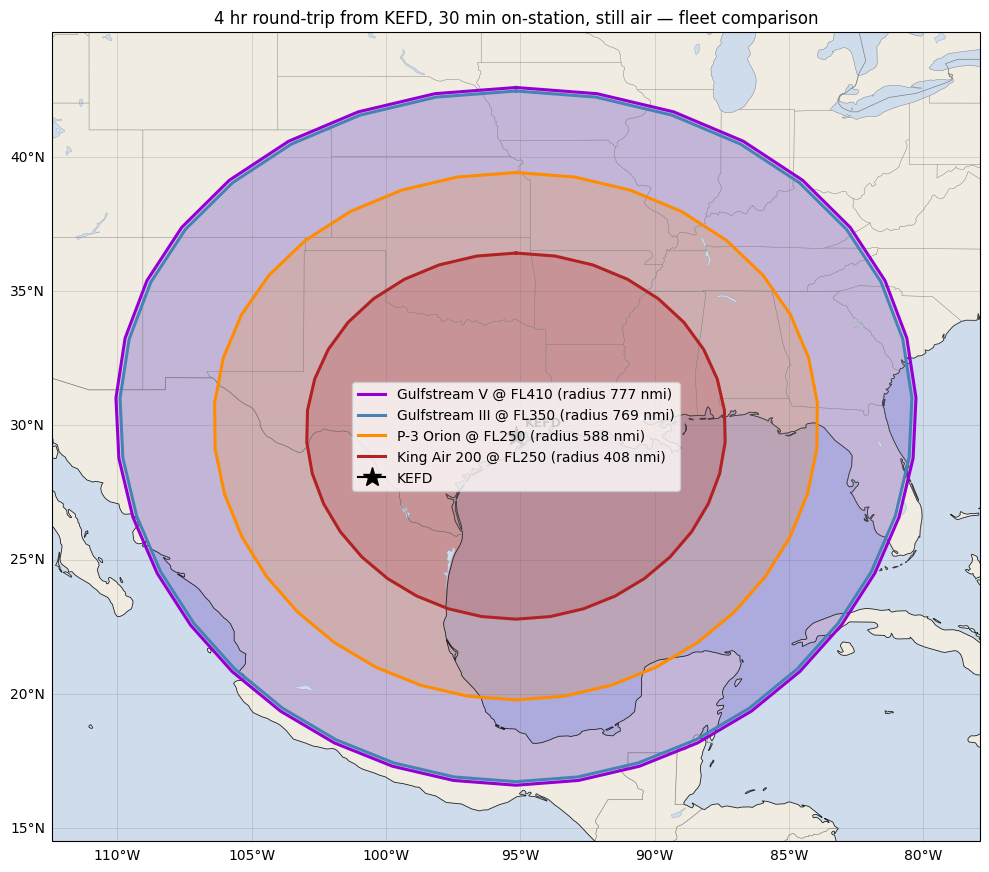

In [21]:
fleet = [
    (NASA_GV(), 41000 * ureg.feet, "darkviolet"),
    (NASA_GIII(), 35000 * ureg.feet, "steelblue"),
    (NASA_P3(), 25000 * ureg.feet, "darkorange"),
    (KingAirB200(), 25000 * ureg.feet, "firebrick"),
]

fleet_layers = []
for ac_i, alt_i, color_i in fleet:
    gdf_i = compute_isochrone(
        aircraft=ac_i, start=kefd, budget=4 * ureg.hour,
        cruise_altitude=alt_i, mode="round_trip",
        on_station_time=30 * ureg.minute,
        wind_source=StillAirField(),
        azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
        distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
    )
    fl = int(alt_i.m_as(ureg.feet) / 100)
    label = (
        f"{ac_i.aircraft_type} @ FL{fl:03d} "
        f"(radius {gdf_i.distance_nmi.mean():.0f} nmi)"
    )
    fleet_layers.append((gdf_i, color_i, label))

plot_isochrone_layers(
    fleet_layers,
    points=[{"lon": kefd.longitude, "lat": kefd.latitude,
             "label": "KEFD", "color": "black"}],
    title="4 hr round-trip from KEFD, 30 min on-station, still air — fleet comparison",
    figsize=(10, 10),
)
_show_plot()


## 8. MERRA-2 reanalysis: real wind on a real date

Constant wind is useful for intuition, but real isochrones are usually drawn against historical or forecast wind data. The MERRA-2 reanalysis covers 1980–present at ~0.5° resolution, 3-hourly cadence, on 42 pressure levels — useful for "what was the wind on this campaign date?" planning.

**Prerequisites:** install `hyplan[winds]`, register at [urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov), and either set `EARTHDATA_TOKEN` or add credentials to `~/.netrc`. To avoid surprise network fetches during routine notebook execution, this demo is opt-in: set `HYPLAN_RUN_MERRA2_DEMO=1` before running the notebook.

Pick a winter date when the polar jet often dips into the western US. Bound the MERRA-2 fetch generously around the expected B-200 isochrone footprint. MERRA-2 hands back data on pressure levels; the gridded provider interpolates to the requested geometric altitude internally.

In [22]:
import datetime as dt
import os

run_merra2_demo = os.environ.get("HYPLAN_RUN_MERRA2_DEMO") == "1"
has_earthdata = bool(
    os.environ.get("EARTHDATA_TOKEN")
    or os.path.exists(os.path.expanduser("~/.netrc"))
)

if run_merra2_demo and has_earthdata:
    from hyplan.winds import MERRA2WindField

    takeoff_time = dt.datetime(2024, 1, 15, 18, 0, tzinfo=dt.timezone.utc)

    wf_merra2 = MERRA2WindField(
        lat_min=15.0, lat_max=45.0,
        lon_min=-115.0, lon_max=-75.0,
        time_start=takeoff_time,
        time_end=takeoff_time + dt.timedelta(hours=7),
    )

    gdf_merra2 = compute_isochrone(
        aircraft=ac, start=kefd,
        budget=mission_budget,
        cruise_altitude=cruise_altitude,
        mode="round_trip",
        on_station_time=on_station,
        reserve=reserve,
        wind_source=wf_merra2,
        azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
        distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
        start_time=takeoff_time,
    )

    fl = int(cruise_altitude.m_as(ureg.feet) / 100)
    plot_isochrone_layers(
        [
            (gdf_calm, "steelblue", "still air"),
            (gdf_wind, "firebrick", "60 kt constant west wind"),
            (gdf_merra2, "goldenrod", f"MERRA-2 {takeoff_time.date().isoformat()}"),
        ],
        points=[{"lon": kefd.longitude, "lat": kefd.latitude, "label": "KEFD", "color": "black"}],
        title="B-200 round-trip isochrone — still air vs. constant 60 kt vs. MERRA-2",
        figsize=(10, 9),
        wind_field=wf_merra2,
        wind_altitude=cruise_altitude,
        wind_time=takeoff_time,
        wind_caption=(
            f"MERRA-2 wind barbs at FL{fl:03d}, "
            f"{takeoff_time.strftime('%Y-%m-%d %HZ')}"
        ),
    )
    _show_plot()

    print(f"MERRA-2 mean radius: {gdf_merra2.distance_nmi.mean():.0f} nmi "
          f"(range {gdf_merra2.distance_nmi.min():.0f}-{gdf_merra2.distance_nmi.max():.0f} nmi)")
    print(f"MERRA-2 mean |net headwind|: "
          f"{gdf_merra2.net_headwind_kt.abs().mean():.1f} kt")
    asym = gdf_merra2.headwind_asymmetry_kt.abs().max()
    where = gdf_merra2.iloc[gdf_merra2.headwind_asymmetry_kt.abs().idxmax()]
    print(f"max |headwind asymmetry|: {asym:.1f} kt at azimuth {where.azimuth_deg:.0f}°")
else:
    print("Skipping MERRA-2 demo — set HYPLAN_RUN_MERRA2_DEMO=1 and configure Earthdata credentials to run it.")
    print("See https://urs.earthdata.nasa.gov to register; the section above ")
    print("renders identically once credentials are available.")

Skipping MERRA-2 demo — set HYPLAN_RUN_MERRA2_DEMO=1 and configure Earthdata credentials to run it.
See https://urs.earthdata.nasa.gov to register; the section above 
renders identically once credentials are available.


## 9. Folium interactive map

`plot_isochrone(gdf, ...)` returns a Folium map you can pan and zoom — and click on each ray's boundary point to see its diagnostics.  The `tiles=` parameter selects the basemap; the example below uses CartoDB Positron, a clean light-gray tileset that works well behind colored polygons for science figures.


In [23]:
# `plot_isochrone` accepts a `tiles` parameter for the basemap.
# Built-in choices include "OpenStreetMap" (default), 
# "CartoDB positron" (clean light gray, good for science figures),
# "CartoDB dark_matter", and "Esri.WorldImagery" (satellite).
m = plot_isochrone(
    gdf_return,
    color="darkblue",
    tiles="CartoDB positron",
    zoom_start=5,
)
m


## 10. Refuel-extended reach

Some campaigns allow a mid-mission refuel stop at a pre-cleared field.  After landing and refueling for ~30–60 min, the aircraft has a full sortie tank again — but a wall-clock **flight-day budget** continues to tick down (covering all flying *plus* the refuel).

`compute_refuel_isochrone` extends each ray's reach by trying three itineraries per azimuth (direct / outbound-refuel / return-refuel) and picking the one that goes farthest while honoring both the per-cycle `sortie_budget` and the total `flight_day_budget`.

Below: KEFD departure, KLBB as the refuel candidate, KEFD as the recovery field.  B-200 with `sortie_budget=4 hr`, `flight_day_budget=8 hr`, `refuel_time=30 min`.


itineraries: {'direct': 23, 'outbound_refuel': 13}
refuel airports used: ['KLBB']


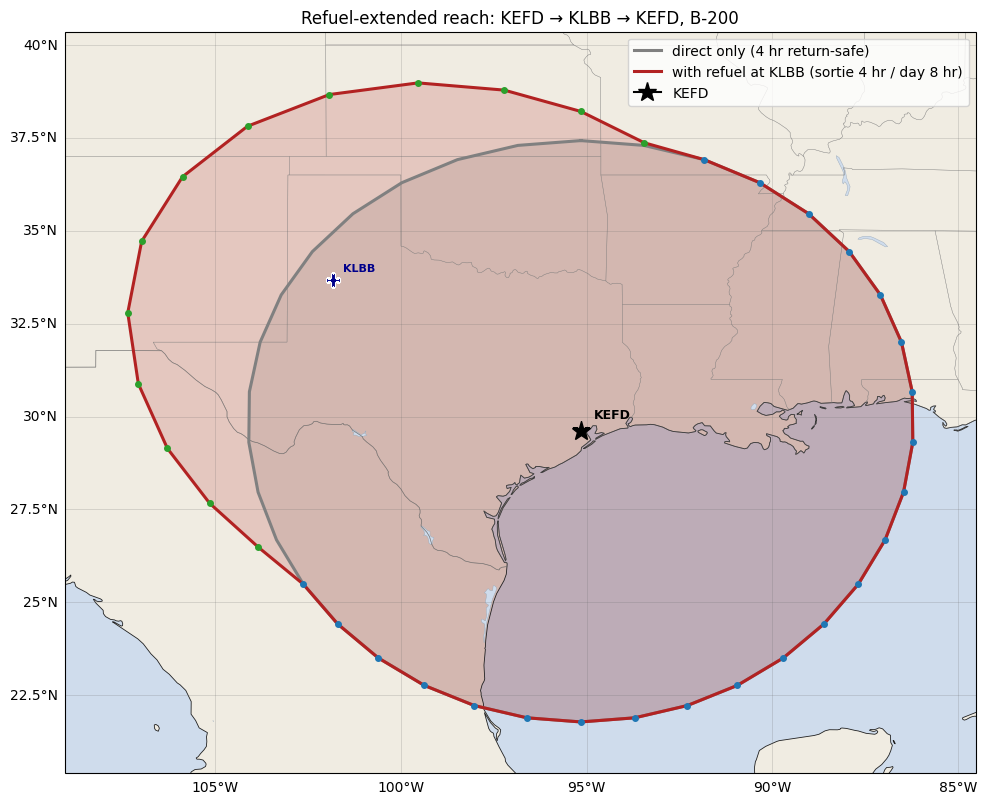

In [24]:
from hyplan import compute_refuel_isochrone

kefd = Airport("KEFD")
klbb = Airport("KLBB")
ac = KingAirB200()
cruise_altitude = 25000 * ureg.feet

gdf_direct = compute_isochrone(
    aircraft=ac, start=kefd, budget=4 * ureg.hour,
    cruise_altitude=cruise_altitude,
    return_destination=kefd, mode="return_safe",
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)
gdf_refuel = compute_refuel_isochrone(
    aircraft=ac, start=kefd,
    sortie_budget=4 * ureg.hour,
    flight_day_budget=8 * ureg.hour,
    cruise_altitude=cruise_altitude,
    refuel_airports=[klbb],
    refuel_time=30 * ureg.minute,
    return_destination=kefd,
    mode="return_safe",
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)

print("itineraries:", gdf_refuel["itinerary"].value_counts().to_dict())
print("refuel airports used:", gdf_refuel.attrs["refuel_airports_used"])

# Plot the two boundaries on the same axes; color refuel-isochrone
# rays by their winning itinerary.
itinerary_colors = {
    "direct": "#1f77b4",
    "outbound_refuel": "#2ca02c",
    "return_refuel": "#d62728",
}
fig, ax = plot_isochrone_layers(
    [
        (gdf_direct, "0.5", "direct only (4 hr return-safe)"),
        (gdf_refuel, "firebrick", "with refuel at KLBB (sortie 4 hr / day 8 hr)"),
    ],
    # KLBB is auto-rendered by plot_isochrone_static from the refuel
    # gdf's attrs, so we only pass start/recovery markers here.
    points=[
        {"lon": kefd.longitude, "lat": kefd.latitude, "label": "KEFD", "color": "black"},
    ],
    title="Refuel-extended reach: KEFD → KLBB → KEFD, B-200",
    figsize=(10, 9),
)
for _, row in gdf_refuel.iterrows():
    ax.plot(
        row["target_lon"], row["target_lat"], marker="o",
        color=itinerary_colors.get(row["itinerary"], "gray"),
        markersize=4, transform=PLATE_CARREE,
    )


## 11. Concentric reach: how far in 1 / 2 / 3 / 4 hours?

`compute_concentric_isochrones(...)` sweeps multiple budgets in one call and amortizes the bracket search across them — each budget's solver is seeded by the previous (smaller) budget's converged distances per ray, so total cost is roughly O(M+N) instead of O(M·N) for M budgets and N rays.

`plot_isochrone_static` recognizes the resulting GeoDataFrame (it has a `budget_hr` column) and auto-renders one nested polygon per budget with a viridis color ramp.


budgets evaluated: [1.0, 2.0, 3.0, 4.0]
budget_hr
1.0     81.789258
2.0    199.662012
3.0    318.737549
4.0    438.013550
Name: max reach (nmi), dtype: float64


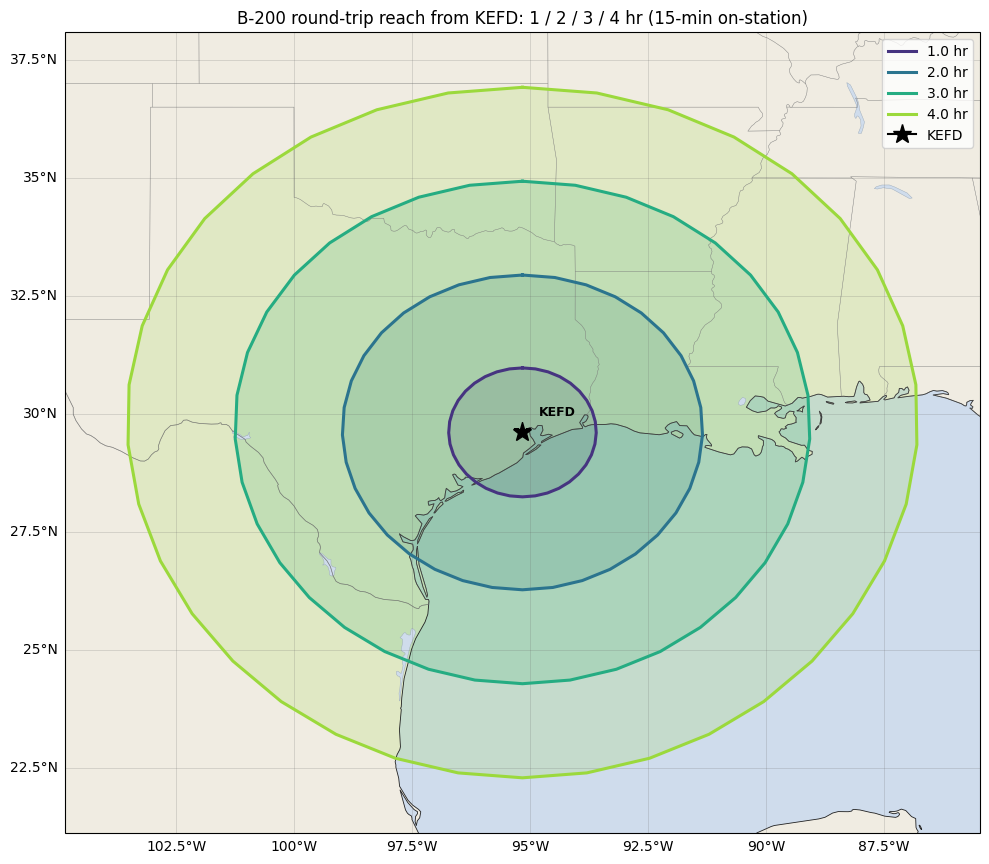

In [25]:
ac = KingAirB200()
kefd = Airport("KEFD")
cruise_altitude = 25000 * ureg.feet

gdf_concentric = compute_concentric_isochrones(
    aircraft=ac, start=kefd,
    budgets=[1 * ureg.hour, 2 * ureg.hour, 3 * ureg.hour, 4 * ureg.hour],
    cruise_altitude=cruise_altitude,
    mode="round_trip",
    on_station_time=15 * ureg.minute,
    azimuth_resolution_deg=AZIMUTH_RESOLUTION_DEG,
    distance_tolerance_nmi=DISTANCE_TOLERANCE_NMI,
)
print("budgets evaluated:", gdf_concentric.attrs["budgets_hr"])
print(gdf_concentric.groupby("budget_hr")["distance_nmi"].max().rename("max reach (nmi)"))

fig, ax = plot_isochrone_static(
    gdf_concentric,
    points=[{"lon": kefd.longitude, "lat": kefd.latitude, "label": "KEFD", "color": "black"}],
    title="B-200 round-trip reach from KEFD: 1 / 2 / 3 / 4 hr (15-min on-station)",
    figsize=(10, 9),
)


## 12. Spot-check a single target: `evaluate_target_reachability`

Sometimes the question isn't "where can I observe?" but "can I reach *this point*?".  `evaluate_target_reachability(...)` is the complement of `compute_refuel_isochrone`: same direct/refuel logic, single point in, structured dict out describing the best route plus all feasible alternatives.

Below: B-200 from KEFD asks whether a target at (35° N, 103° W — out near the New Mexico/Texas border) is reachable for a return-safe sortie to KBTR with KLBB available as a refuel candidate.


In [26]:
klbb = Airport("KLBB")
kbtr = Airport("KBTR")

target = Waypoint(
    latitude=35.0, longitude=-103.0,
    heading=0.0, altitude_msl=cruise_altitude,
    name="target",
)

result = evaluate_target_reachability(
    aircraft=ac, start=kefd, target=target,
    sortie_budget=4 * ureg.hour,
    flight_day_budget=8 * ureg.hour,
    cruise_altitude=cruise_altitude,
    refuel_airports=[klbb],
    refuel_time=30 * ureg.minute,
    return_destination=kbtr,
    mode="return_safe",
)

print(f"reachable: {result['reachable']}")
if result["best"]:
    b = result["best"]
    print(
        f"best: {b['itinerary']}"
        f"{' via ' + b['refuel_airport'] if b['refuel_airport'] else ''}"
        f", day total = {b['day_total_time_min']:.1f} min, "
        f"sortie margin = {b['sortie_margin_min']:.1f} min"
    )
    print(f"alternatives: {len(result['alternatives'])}")
    for a in result["alternatives"]:
        print(
            f"  - {a['itinerary']}"
            f"{' via ' + a['refuel_airport'] if a['refuel_airport'] else ''}"
            f", day total = {a['day_total_time_min']:.1f} min"
        )
else:
    print("unreachable:", result["unreachable_reason"])


reachable: True
best: outbound_refuel via KLBB, day total = 332.3 min, sortie margin = 46.6 min
alternatives: 1
  - return_refuel via KLBB, day total = 335.7 min


## Operational takeaways

- **Round-trip ≠ one-way × 2**: climb / descent overhead and any recovery requirement mean a round-trip envelope is not simply half of a one-way envelope at the same total budget.
- **Wind matters more for one-way than round-trip**: round-trip wind effects largely cancel; one-way reach can shift by tens of nmi per knot of mean along-track wind.
- **`return_safe` ≠ `round_trip` even when both endpoints are at the same airport**: identical only if `return_destination is None` defaults make them equivalent. Whenever the recovery airport is somewhere else, the envelope is asymmetric.
- **Diagnostics tell you *why***: the per-ray `outbound_headwind_kt`, `return_headwind_kt`, `net_headwind_kt`, `headwind_asymmetry_kt`, and `limiting_leg` columns make it easy to debug an envelope shape that looks unexpected.

## Common pitfalls

- **`start.altitude_msl` is required.** For pre-flight, pass the airport's runway elevation. For in-flight, pass the current cruise altitude.
- **`reserve` is in *time*, not fuel.** It's how much of the endurance budget must remain unflown at boundary convergence.
- **`one_way` mode ignores `return_destination`** (with a warning). If you want round-trip envelopes, use `mode="round_trip"` or `mode="return_safe"`.
- **`on_station_altitude ≠ cruise_altitude` is a v1 error**, not a silent coercion. Multi-altitude isochrones (descend for observation, climb back for return) are deferred to a future release.

## Summary

| Mode | Use case | `return_destination` |
|------|---------|---------------------|
| `one_way` | opportunistic in-flight re-tasking, transit-to-downrange-base | ignored |
| `round_trip` | campaign site-selection from one base | optional (defaults to `start`) |
| `return_safe` | recovery at a different airport, in-flight diversion planning | required |
